In [1]:
!pip install scanpy anndata leidenalg python-igraph shap celltypist -q

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

PROJECT_DIR = '/content/drive/MyDrive/pbmc3k-scrna-shap'
DATA_DIR = f'{PROJECT_DIR}/data'
RESULTS_DIR = f'{PROJECT_DIR}/results'
RANDOM_STATE = 42

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
adata = sc.read_h5ad(f'{DATA_DIR}/pbmc3k_annotated.h5ad')
print(adata)
print(adata.obs['cell_type'].value_counts())

AnnData object with n_obs × n_vars = 2638 × 2013
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'cell_type'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'cell_type_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
    layers: 'counts', 'lognorm', None (.X)
cell_type
CD4 T            1179
CD14 Mono         445
B cell            344
CD8 T             268
FCGR3A Mono       199
NK                159
DC                 31
Megakaryocyte      13
Name: count, dtype: int64


In [8]:
# Use the union of top differential-expression marker genes per cluster
# (from rank_genes_groups in Notebook 1+2) as the classifier's feature set,
# rather than genes ranked by dispersion alone. Dispersion-based ranking
# surfaces genes variable within their expression bin, which doesn't
# guarantee they're the genes that actually separate cell types --
# for classification we want strong between-cluster signal instead.

top_markers_table = pd.read_csv(f'{RESULTS_DIR}/top_marker_genes_per_cluster.csv')
top_genes = sorted(set(top_markers_table.values.flatten()))

print(f'Selected {len(top_genes)} unique marker genes across all clusters')
print(top_genes[:10])

Selected 65 unique marker genes across all clusters
['AIF1', 'B2M', 'CALM3', 'CCL5', 'CD37', 'CD3D', 'CD74', 'CD79A', 'CD79B', 'COTL1']


In [9]:
X = adata.raw[:, top_genes].X
if not isinstance(X, np.ndarray):
    X = X.toarray()
X = pd.DataFrame(X, columns=top_genes, index=adata.obs_names)

y = adata.obs['cell_type'].values

print(f'Feature matrix shape: {X.shape}')
print(f'Classes: {sorted(set(y))}')

Feature matrix shape: (2638, 65)
Classes: ['B cell', 'CD14 Mono', 'CD4 T', 'CD8 T', 'DC', 'FCGR3A Mono', 'Megakaryocyte', 'NK']


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (1978, 65), Test: (660, 65)


In [11]:
clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total n

               precision    recall  f1-score   support

       B cell       1.00      1.00      1.00        86
    CD14 Mono       0.92      0.98      0.95       111
        CD4 T       0.97      0.99      0.98       295
        CD8 T       0.90      0.85      0.88        67
           DC       0.88      0.88      0.88         8
  FCGR3A Mono       0.98      0.84      0.90        50
Megakaryocyte       1.00      0.67      0.80         3
           NK       0.97      0.93      0.95        40

     accuracy                           0.96       660
    macro avg       0.95      0.89      0.92       660
 weighted avg       0.96      0.96      0.96       660



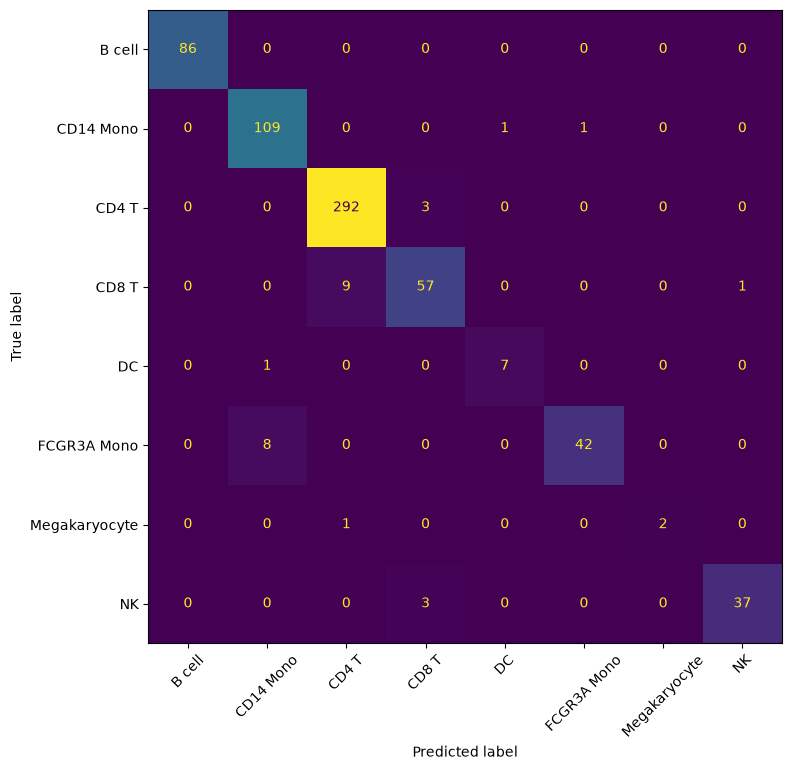

In [12]:
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/shap_classifier_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    class_names = clf.classes_
else:
    class_names = clf.classes_
    shap_values = [shap_values[:, :, i] for i in range(shap_values.shape[2])]

print(f'Number of classes explained: {len(shap_values)}')
print(f'SHAP values shape per class: {shap_values[0].shape}')

Number of classes explained: 8
SHAP values shape per class: (660, 65)


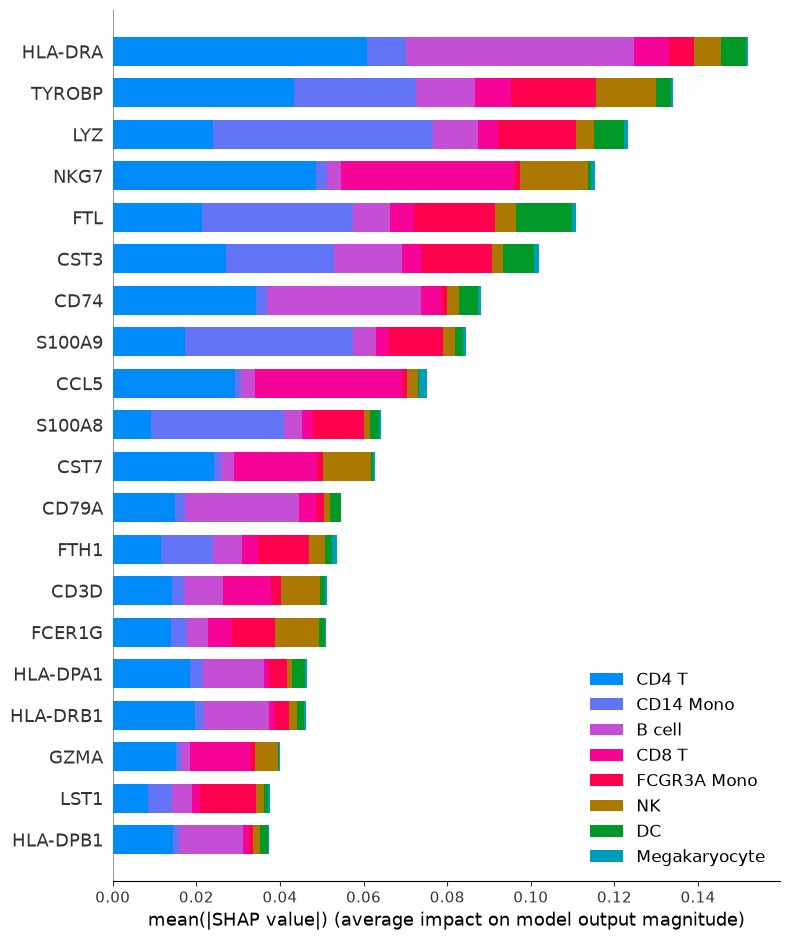

In [14]:
shap.summary_plot(shap_values, X_test, class_names=class_names, show=False)
plt.savefig(f'{RESULTS_DIR}/shap_summary_all_classes.png', dpi=150, bbox_inches='tight')
plt.show()

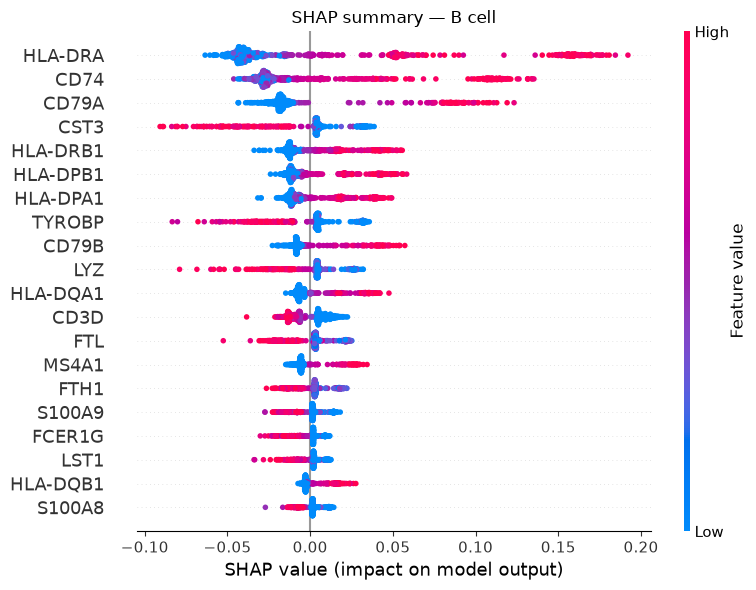

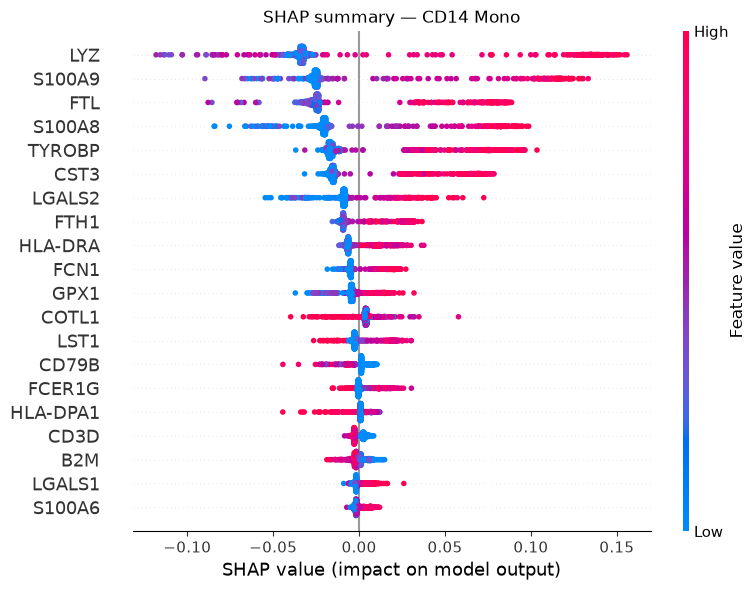

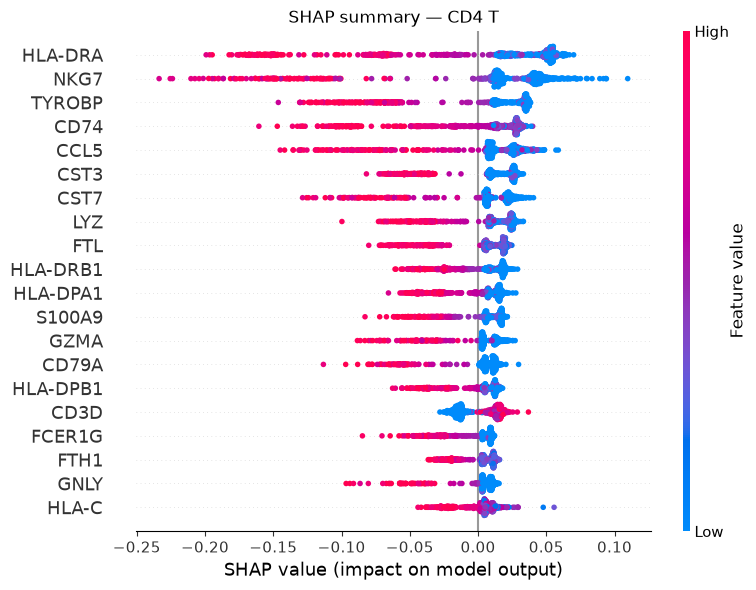

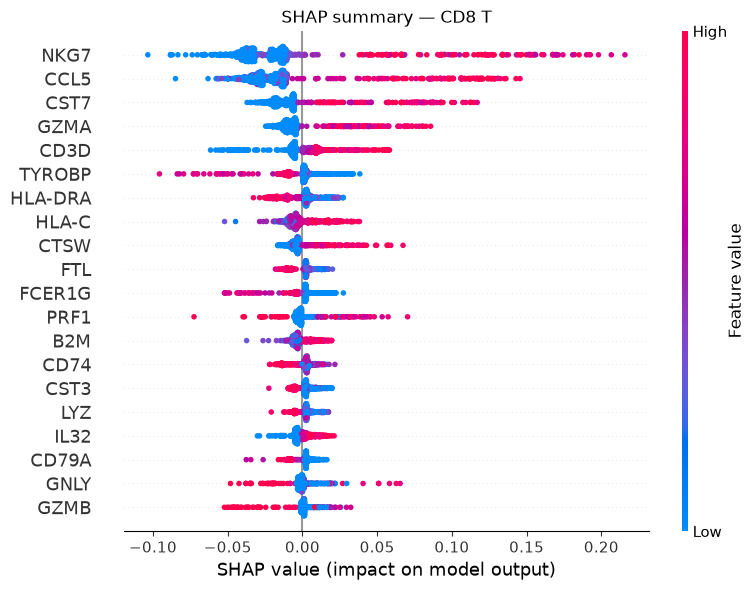

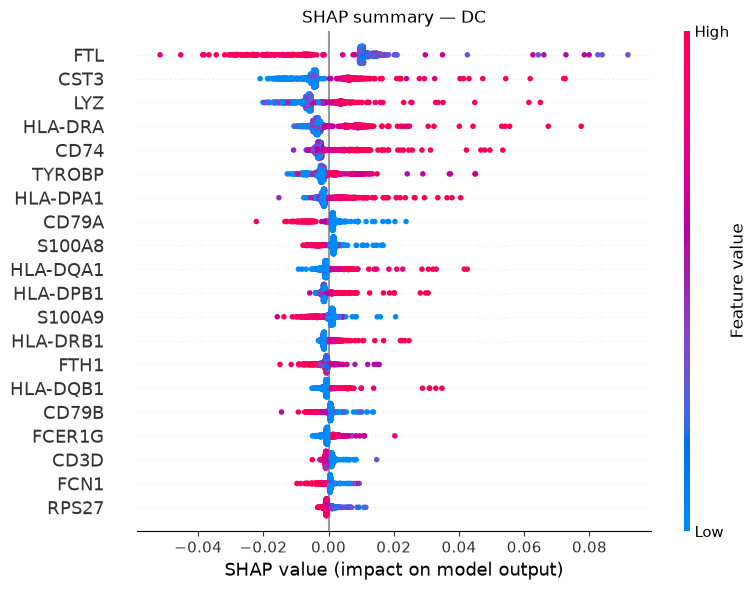

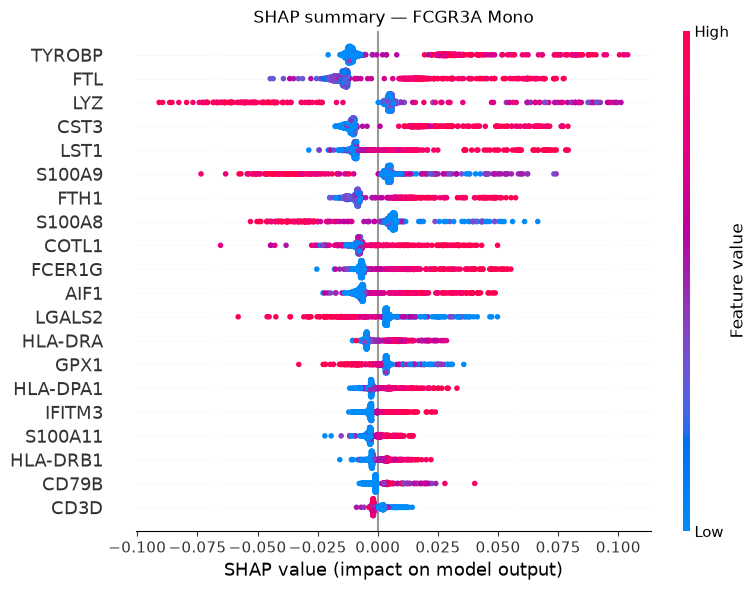

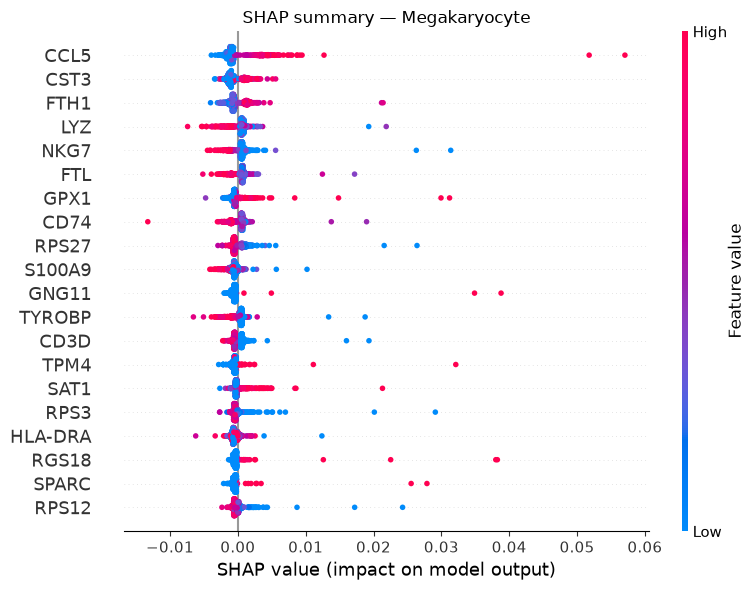

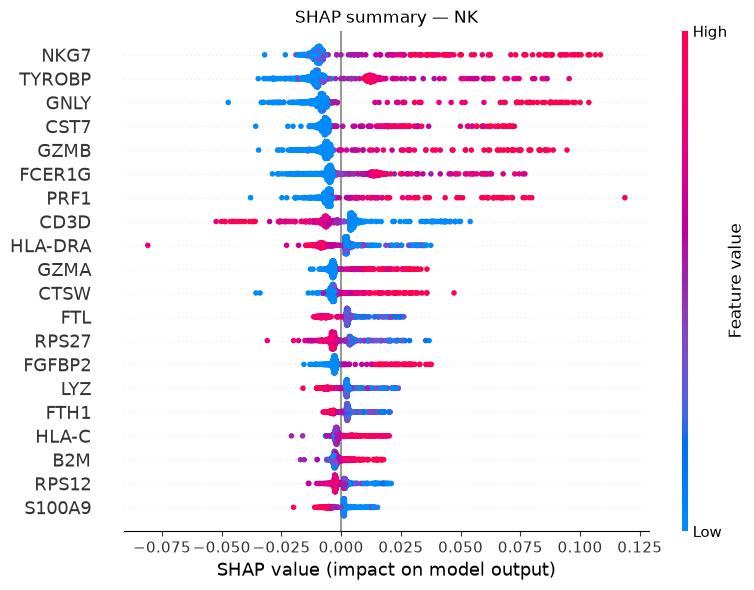

In [15]:
for i, cname in enumerate(class_names):
    plt.figure()
    shap.summary_plot(shap_values[i], X_test, show=False, plot_size=(8, 6))
    plt.title(f'SHAP summary — {cname}')
    plt.tight_layout()
    safe_name = str(cname).replace(' ', '_').replace('+', 'plus')
    plt.savefig(f'{RESULTS_DIR}/shap_summary_{safe_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [16]:
import os
saved = [f for f in os.listdir(RESULTS_DIR) if f.startswith('shap_summary_') and f.endswith('.png') and 'all_classes' not in f]
print(sorted(saved))
print(f"\nExpected classes: {sorted(class_names)}")

['shap_summary_B_cell.png', 'shap_summary_CD14_Mono.png', 'shap_summary_CD4_T.png', 'shap_summary_CD8_T.png', 'shap_summary_DC.png', 'shap_summary_FCGR3A_Mono.png', 'shap_summary_Megakaryocyte.png', 'shap_summary_NK.png']

Expected classes: ['B cell', 'CD14 Mono', 'CD4 T', 'CD8 T', 'DC', 'FCGR3A Mono', 'Megakaryocyte', 'NK']


In [17]:
def top_shap_genes(shap_vals_for_class, feature_names, n=10):
    mean_abs_shap = np.abs(shap_vals_for_class).mean(axis=0)
    order = np.argsort(mean_abs_shap)[::-1][:n]
    return [(feature_names[i], mean_abs_shap[i]) for i in order]

shap_top_genes = {}
for i, cname in enumerate(class_names):
    top = top_shap_genes(shap_values[i], top_genes, n=10)
    shap_top_genes[cname] = [g for g, _ in top]
    print(f'{cname}: {[g for g, _ in top]}')

B cell: ['HLA-DRA', 'CD74', 'CD79A', 'CST3', 'HLA-DRB1', 'HLA-DPB1', 'HLA-DPA1', 'TYROBP', 'CD79B', 'LYZ']
CD14 Mono: ['LYZ', 'S100A9', 'FTL', 'S100A8', 'TYROBP', 'CST3', 'LGALS2', 'FTH1', 'HLA-DRA', 'FCN1']
CD4 T: ['HLA-DRA', 'NKG7', 'TYROBP', 'CD74', 'CCL5', 'CST3', 'CST7', 'LYZ', 'FTL', 'HLA-DRB1']
CD8 T: ['NKG7', 'CCL5', 'CST7', 'GZMA', 'CD3D', 'TYROBP', 'HLA-DRA', 'HLA-C', 'CTSW', 'FTL']
DC: ['FTL', 'CST3', 'LYZ', 'HLA-DRA', 'CD74', 'TYROBP', 'HLA-DPA1', 'CD79A', 'S100A8', 'HLA-DQA1']
FCGR3A Mono: ['TYROBP', 'FTL', 'LYZ', 'CST3', 'LST1', 'S100A9', 'FTH1', 'S100A8', 'COTL1', 'FCER1G']
Megakaryocyte: ['CCL5', 'CST3', 'FTH1', 'LYZ', 'NKG7', 'FTL', 'GPX1', 'CD74', 'RPS27', 'S100A9']
NK: ['NKG7', 'TYROBP', 'GNLY', 'CST7', 'GZMB', 'FCER1G', 'PRF1', 'CD3D', 'HLA-DRA', 'GZMA']


In [18]:
de_top_markers = pd.read_csv(f'{RESULTS_DIR}/top_marker_genes_per_cluster.csv')

cluster_to_celltype = (
    adata.obs[['leiden', 'cell_type']]
    .drop_duplicates()
    .set_index('leiden')['cell_type']
    .to_dict()
)
print(cluster_to_celltype)

{'0': 'CD4 T', '2': 'B cell', '4': 'FCGR3A Mono', '5': 'NK', '3': 'CD8 T', '1': 'CD14 Mono', '6': 'DC', '7': 'Megakaryocyte'}


In [19]:
comparison_rows = []
for cluster_num, cname in cluster_to_celltype.items():
    if cname not in shap_top_genes:
        continue
    de_genes = set(de_top_markers[str(cluster_num)].dropna().tolist())
    shap_genes = set(shap_top_genes[cname])
    overlap = de_genes & shap_genes
    comparison_rows.append({
        'cell_type': cname,
        'cluster': cluster_num,
        'n_overlap': len(overlap),
        'overlap_genes': sorted(overlap),
        'de_only': sorted(de_genes - shap_genes),
        'shap_only': sorted(shap_genes - de_genes),
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(f'{RESULTS_DIR}/shap_vs_de_comparison.csv', index=False)
comparison_df

,cell_type,cluster,n_overlap,overlap_genes,de_only,shap_only
0,CD4 T,0,0,[],"[CD3D, LDHB, RPL31, RPS12, RPS14, RPS25, RPS27...","[CCL5, CD74, CST3, CST7, FTL, HLA-DRA, HLA-DRB..."
1,B cell,2,6,"[CD74, CD79A, CD79B, HLA-DPB1, HLA-DRA, HLA-DRB1]","[CD37, HLA-DQA1, HLA-DQB1, MS4A1]","[CST3, HLA-DPA1, LYZ, TYROBP]"
2,FCGR3A Mono,4,5,"[COTL1, FCER1G, FTH1, FTL, LST1]","[AIF1, IFITM3, PSAP, S100A11, SAT1]","[CST3, LYZ, S100A8, S100A9, TYROBP]"
3,NK,5,6,"[CST7, GNLY, GZMA, GZMB, NKG7, PRF1]","[B2M, CTSW, FGFBP2, HLA-C]","[CD3D, FCER1G, HLA-DRA, TYROBP]"
4,CD8 T,3,7,"[CCL5, CD3D, CST7, CTSW, GZMA, HLA-C, NKG7]","[B2M, HLA-A, IL32]","[FTL, HLA-DRA, TYROBP]"
5,CD14 Mono,1,8,"[CST3, FCN1, FTL, LGALS2, LYZ, S100A8, S100A9,...","[LGALS1, S100A6]","[FTH1, HLA-DRA]"
6,DC,6,5,"[CD74, CST3, HLA-DPA1, HLA-DQA1, HLA-DRA]","[HLA-DMA, HLA-DPB1, HLA-DQB1, HLA-DRB1, HLA-DRB5]","[CD79A, FTL, LYZ, S100A8, TYROBP]"
7,Megakaryocyte,7,1,[GPX1],"[CALM3, GNG11, NRGN, PF4, PPBP, RGS18, SDPR, S...","[CCL5, CD74, CST3, FTH1, FTL, LYZ, NKG7, RPS27..."


In [20]:
print("=== SHAP vs. Differential Expression: Summary ===\n")
for _, row in comparison_df.iterrows():
    print(f"{row['cell_type']}: {row['n_overlap']}/10 overlap")
print(f"\nMean overlap: {comparison_df['n_overlap'].mean():.1f}/10")

=== SHAP vs. Differential Expression: Summary ===

CD4 T: 0/10 overlap
B cell: 6/10 overlap
FCGR3A Mono: 5/10 overlap
NK: 6/10 overlap
CD8 T: 7/10 overlap
CD14 Mono: 8/10 overlap
DC: 5/10 overlap
Megakaryocyte: 1/10 overlap

Mean overlap: 4.8/10
